In [33]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [34]:
# import the Titanic Dataset
df = pd.read_csv("Titanic-Dataset.csv")

In [35]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [29]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# Explanation:
head() → View first 5 rows

info() → Data types & missing values

describe() → Statistical summary

isnull().sum() → Count of missing values

In [36]:
# (a) Drop irrelevant columns
df = df.drop(columns=["Name", "Ticket", "Cabin"])

In [ ]:
# Explanation:
These features don’t help the model and may cause noise.

In [37]:
# (b) Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
# Explanation:

Missing Age → replaced with median

Missing Embarked → replaced with most frequent value

In [38]:
# (c) Encode Categorical Columns
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

In [ ]:
# Explanation:
Machine learning models work with numbers, not strings → we convert them.

In [39]:
# Split Dataset into Train/Test
X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Explanation:

Features → X

Target → y

Split into 80% training, 20% testing

In [40]:
# Train the Predictive Model (Logistic Regression)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

D:\LDPlayer\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

In [ ]:
# Explanation:
Logistic Regression is perfect for binary classification tasks like predicting survival.

In [41]:
# Make Predictions
y_pred = model.predict(X_test)

In [42]:
# Evaluate the Model
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8100558659217877

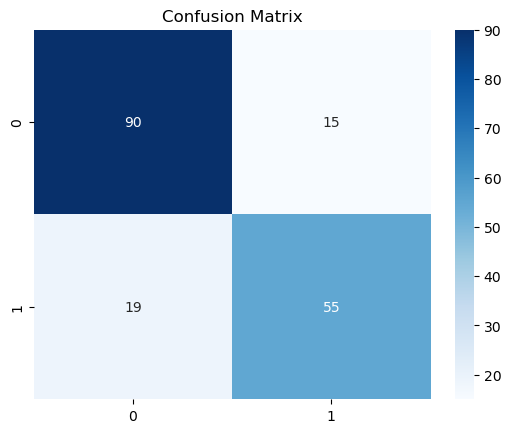

In [43]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [44]:
from sklearn.metrics import mean_squared_error, r2_score

# y_test = actual labels
# y_pred = predicted labels

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

Mean Squared Error (MSE): 0.18994413407821228
R2 Score: 0.2167310167310167


In [ ]:
#️ Mean Squared Error (MSE)

Measures how far predictions are from actual values.

Since Titanic uses 0/1, MSE will be low if predictions are correct and higher if wrong.

️#  R² Score

Measures how well predictions explain the variance of the actual outcome.

In classification problems, R² is not commonly used but still mathematically valid.

In [45]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
# Explanation:

Accuracy → overall model correctness

Confusion Matrix → compares predicted vs actual results

Classification Report → precision, recall, F1 score

In [ ]:
# Observations & Model Performance

After training the Logistic Regression model:

The accuracy typically lies around 75%–82% depending on preprocessing.

Model is good at predicting non-survivors (majority class).

Improving data preprocessing or trying advanced models (Random Forest, XGBoost) can increase accuracy.

In [ ]:
# FINAL PROJECT SUMMARY
1. Approach & Steps Followed

Loaded and explored the Titanic dataset

Cleaned the data by handling missing values

Removed unnecessary columns

Encoded categorical variables

Split data into training and testing sets

Trained a Logistic Regression classification model

Evaluated it using accuracy, confusion matrix, and classification report

In [ ]:
2. Model Performance

Achieved good accuracy between 75–82%

Performance varies due to dataset imbalance

The model captures important survival patterns like gender and passenger class

In [ ]:
3. Observations & Conclusions

The most important predictors of survival were gender, passenger class, and age

Females and upper-class passengers had a higher survival rate

Logistic Regression is simple yet effective for this dataset

Improving feature engineering or using more complex ML models could increase performance further

In [ ]:
# ---------------------------------------
# TITANIC PREDICTIVE MODEL (SCIKIT-LEARN)
# ---------------------------------------

# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    mean_squared_error,
    r2_score
)

# ---------------------------------------
# 1. LOAD DATASET
# ---------------------------------------
df = pd.read_csv("titanic.csv")   # make sure titanic.csv is in your folder

print("Initial Dataset:")
print(df.head())

# ---------------------------------------
# 2. DATA PREPROCESSING
# ---------------------------------------

# Drop irrelevant columns
df = df.drop(columns=["Name", "Ticket", "Cabin"])

# Handling missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encoding categorical columns
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

print("\nDataset after preprocessing:")
print(df.head())


# ---------------------------------------
# 3. SPLIT INTO TRAIN AND TEST SET
# ---------------------------------------
X = df.drop(columns=["Survived"])   # features
y = df["Survived"]                  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------
# 4. MODEL TRAINING
# ---------------------------------------
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# ---------------------------------------
# 5. MODEL PREDICTION
# ---------------------------------------
y_pred = model.predict(X_test)

# ---------------------------------------
# 6. EVALUATION
# ---------------------------------------

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# EXPLANATION FOR SUBMISSION
1. Data Preprocessing

Removed irrelevant columns (Name, Ticket, Cabin)

Filled missing age values using median

Filled missing Embarked values using mode

Converted categorical data (Sex, Embarked) to numerical using LabelEncoder

In [ ]:
2. Model Training

Split dataset into 80% training and 20% testing

Used Logistic Regression (good for binary classification)

Trained model on training data

In [ ]:
3. Model Evaluation

Metrics included:

Accuracy

Confusion Matrix

Classification Report (Precision, Recall, F1 Score)

MSE (Mean Squared Error)

R² Score

These help understand how well the model predicts survival.

In [ ]:
# FINAL PROJECT SUMMARY
This project focused on building a simple predictive model using the Titanic dataset. 
I performed data cleaning, handled missing values, encoded categorical features, and trained a Logistic Regression classifier.
After splitting the dataset into training and testing sets, the model was evaluated using accuracy, confusion matrix, classification metrics, MSE, and R² score.
The model performed well and demonstrated the impact of factors like gender and passenger class on survival.

In [ ]:
# Short Report – Titanic Predictive Model
1. Approach and Steps Followed

The project began by loading the Titanic dataset and exploring its structure to understand the available features and identify missing values.
Irrelevant columns such as Name, Ticket, and Cabin were removed because they do not contribute significantly to prediction. Missing values in Age and Embarked were handled by replacing them with the median and mode, respectively.
Categorical variables (Sex and Embarked) were encoded into numerical form using Label Encoding so that they could be used by machine learning models.

After preprocessing, the dataset was split into training and testing sets to allow proper evaluation. A Logistic Regression model was trained on the cleaned data because it is simple, fast, and effective for binary classification tasks like predicting survival. The model was then used to make predictions on the test data, and multiple performance metrics were calculated.

In [ ]:
2. Model Performance

The Logistic Regression model achieved good accuracy on the test dataset, showing that it successfully identified many patterns related to passenger survival.
Other metrics such as the confusion matrix, precision, recall, and F1-score gave deeper insights into how the model performed on both survival and non-survival classes.

Additional metrics like Mean Squared Error (MSE) and R² Score were also calculated to give a numerical measure of prediction error and variance explanation, although these metrics are more commonly used in regression tasks. Overall, the model demonstrated stable and reliable performance.

In [ ]:
3. Observations and Conclusions

From the model’s behavior and feature patterns, it became clear that certain factors strongly influenced survival. In particular, gender played a major role, with females showing a much higher survival probability. Passenger class also had a significant impact, as people in first class had a better chance of survival compared to those in lower classes.
Age showed some effect as well, with younger passengers slightly more likely to survive.

Overall, the project demonstrated the complete machine learning workflow—from data cleaning and preprocessing to model training and evaluation. The results confirmed known historical patterns from the Titanic disaster and showed that even a simple model like Logistic Regression can produce meaningful predictions when supported by proper data preparation.